## Import Libraries and Load data

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder


In [2]:
DATA_PATH= './../data'

In [3]:
main_df = pd.read_csv(os.path.join(DATA_PATH,'CNA_SV.csv'))
main_df.head()

,Unnamed: 0,9-Sep_SV,A2BP1_SV,AASDH_SV,AATF_SV,AATK_SV,AATK-AS1_SV,ABCA1_SV,ABCA12_SV,ABCA13_SV,...,TSC2_CNA,TSHR_CNA,U2AF1_CNA,VHL_CNA,WT1_CNA,XPO1_CNA,ZRSR2_CNA,SEX,AGE_AT_SEQ_REPORT,CANCER_TYPE
0,GENIE-DFCI-000024-4434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Female,87,Esophagogastric Cancer
1,GENIE-DFCI-000027-10441,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,Female,74,Soft Tissue Sarcoma
2,GENIE-DFCI-000029-10065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,-1.0,0.0,0.0,0.0,Male,63,Renal Cell Carcinoma
3,GENIE-DFCI-000029-526237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,Male,65,Renal Cell Carcinoma
4,GENIE-DFCI-000035-11184,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,Female,67,CNS Cancer


## Data Preprocessing

In [6]:
df_CNA_SV = main_df[main_df['CANCER_TYPE'] != 'Cancer of Unknown Primary']
test_df = main_df[main_df['CANCER_TYPE'] == 'Cancer of Unknown Primary']


# Filter based on cancer types with more than 1000 instances
cancer_count = df_CNA_SV['CANCER_TYPE'].value_counts()
selected_cancer_types = cancer_count[cancer_count.values > 1000].index.to_list()
df_CNA_SV = df_CNA_SV[df_CNA_SV['CANCER_TYPE'].isin(selected_cancer_types)].reset_index(drop=True)

# Drop columns with zero variation
zero_variation_col = []
for col in df_CNA_SV.columns:
    if len(df_CNA_SV[col].unique()) <= 1:
        zero_variation_col.append(col)


df = df_CNA_SV.copy()
df=df.drop(['Unnamed: 0']+zero_variation_col,axis=1).reset_index(drop=True)

In [7]:
# Encode SEX and CANCER_TYPE
label_encoder_sex = LabelEncoder()
df['SEX'] = label_encoder_sex.fit_transform(df['SEX'])

label_encoder_cancer = LabelEncoder()
df['CANCER_TYPE'] = label_encoder_cancer.fit_transform(df['CANCER_TYPE'])

# Normalize AGE and gene alteration columns
scaler = StandardScaler()
df[['AGE_AT_SEQ_REPORT']] = scaler.fit_transform(df[['AGE_AT_SEQ_REPORT']])

# Correlation Analysis

In [8]:
correlation_matrix = df.corr()
# Specify the column of interest
column_of_interest = 'CANCER_TYPE'

# Extract correlations with the specific column
specific_column_corr = correlation_matrix[[column_of_interest]].sort_values(by=column_of_interest, ascending=False)

specific_column_corr=specific_column_corr[np.abs(specific_column_corr['CANCER_TYPE'].values)>0.02]

import pickle
with open(os.path.join(DATA_PATH,'specific_column_corr.pickle') 'wb') as handle:
    pickle.dump(specific_column_corr, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open(os.path.join(DATA_PATH,'specific_column_corr.pickle'), 'rb') as handle:
    specific_column_corr_loaded = pickle.load(handle)


In [9]:
selected_features=[col for col in df.columns if col not in specific_column_corr_loaded.index.to_list()]

In [10]:
df=df.drop(selected_features,axis=1).reset_index(drop=True)
df.head()

,AGO2_SV,ALK_SV,AR_SV,ARID1B_SV,ARRDC4_SV,ASPSCR1_SV,ATRX_SV,AXIN2_SV,BCAS3_SV,BCL2L11_SV,...,TCF3_CNA,TET2_CNA,TP53_CNA,TSC2_CNA,TSHR_CNA,WT1_CNA,XPO1_CNA,SEX,AGE_AT_SEQ_REPORT,CANCER_TYPE
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0,1.913244,2
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.997837,7
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.575342,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,-1.0,1.0,1.0,0.0,0.0,0,0.857005,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.152846,5


In [137]:
cna_columns = df.filter(like='_CNA').columns.to_list()
sv_columns = df.filter(like='_SV').columns.to_list()

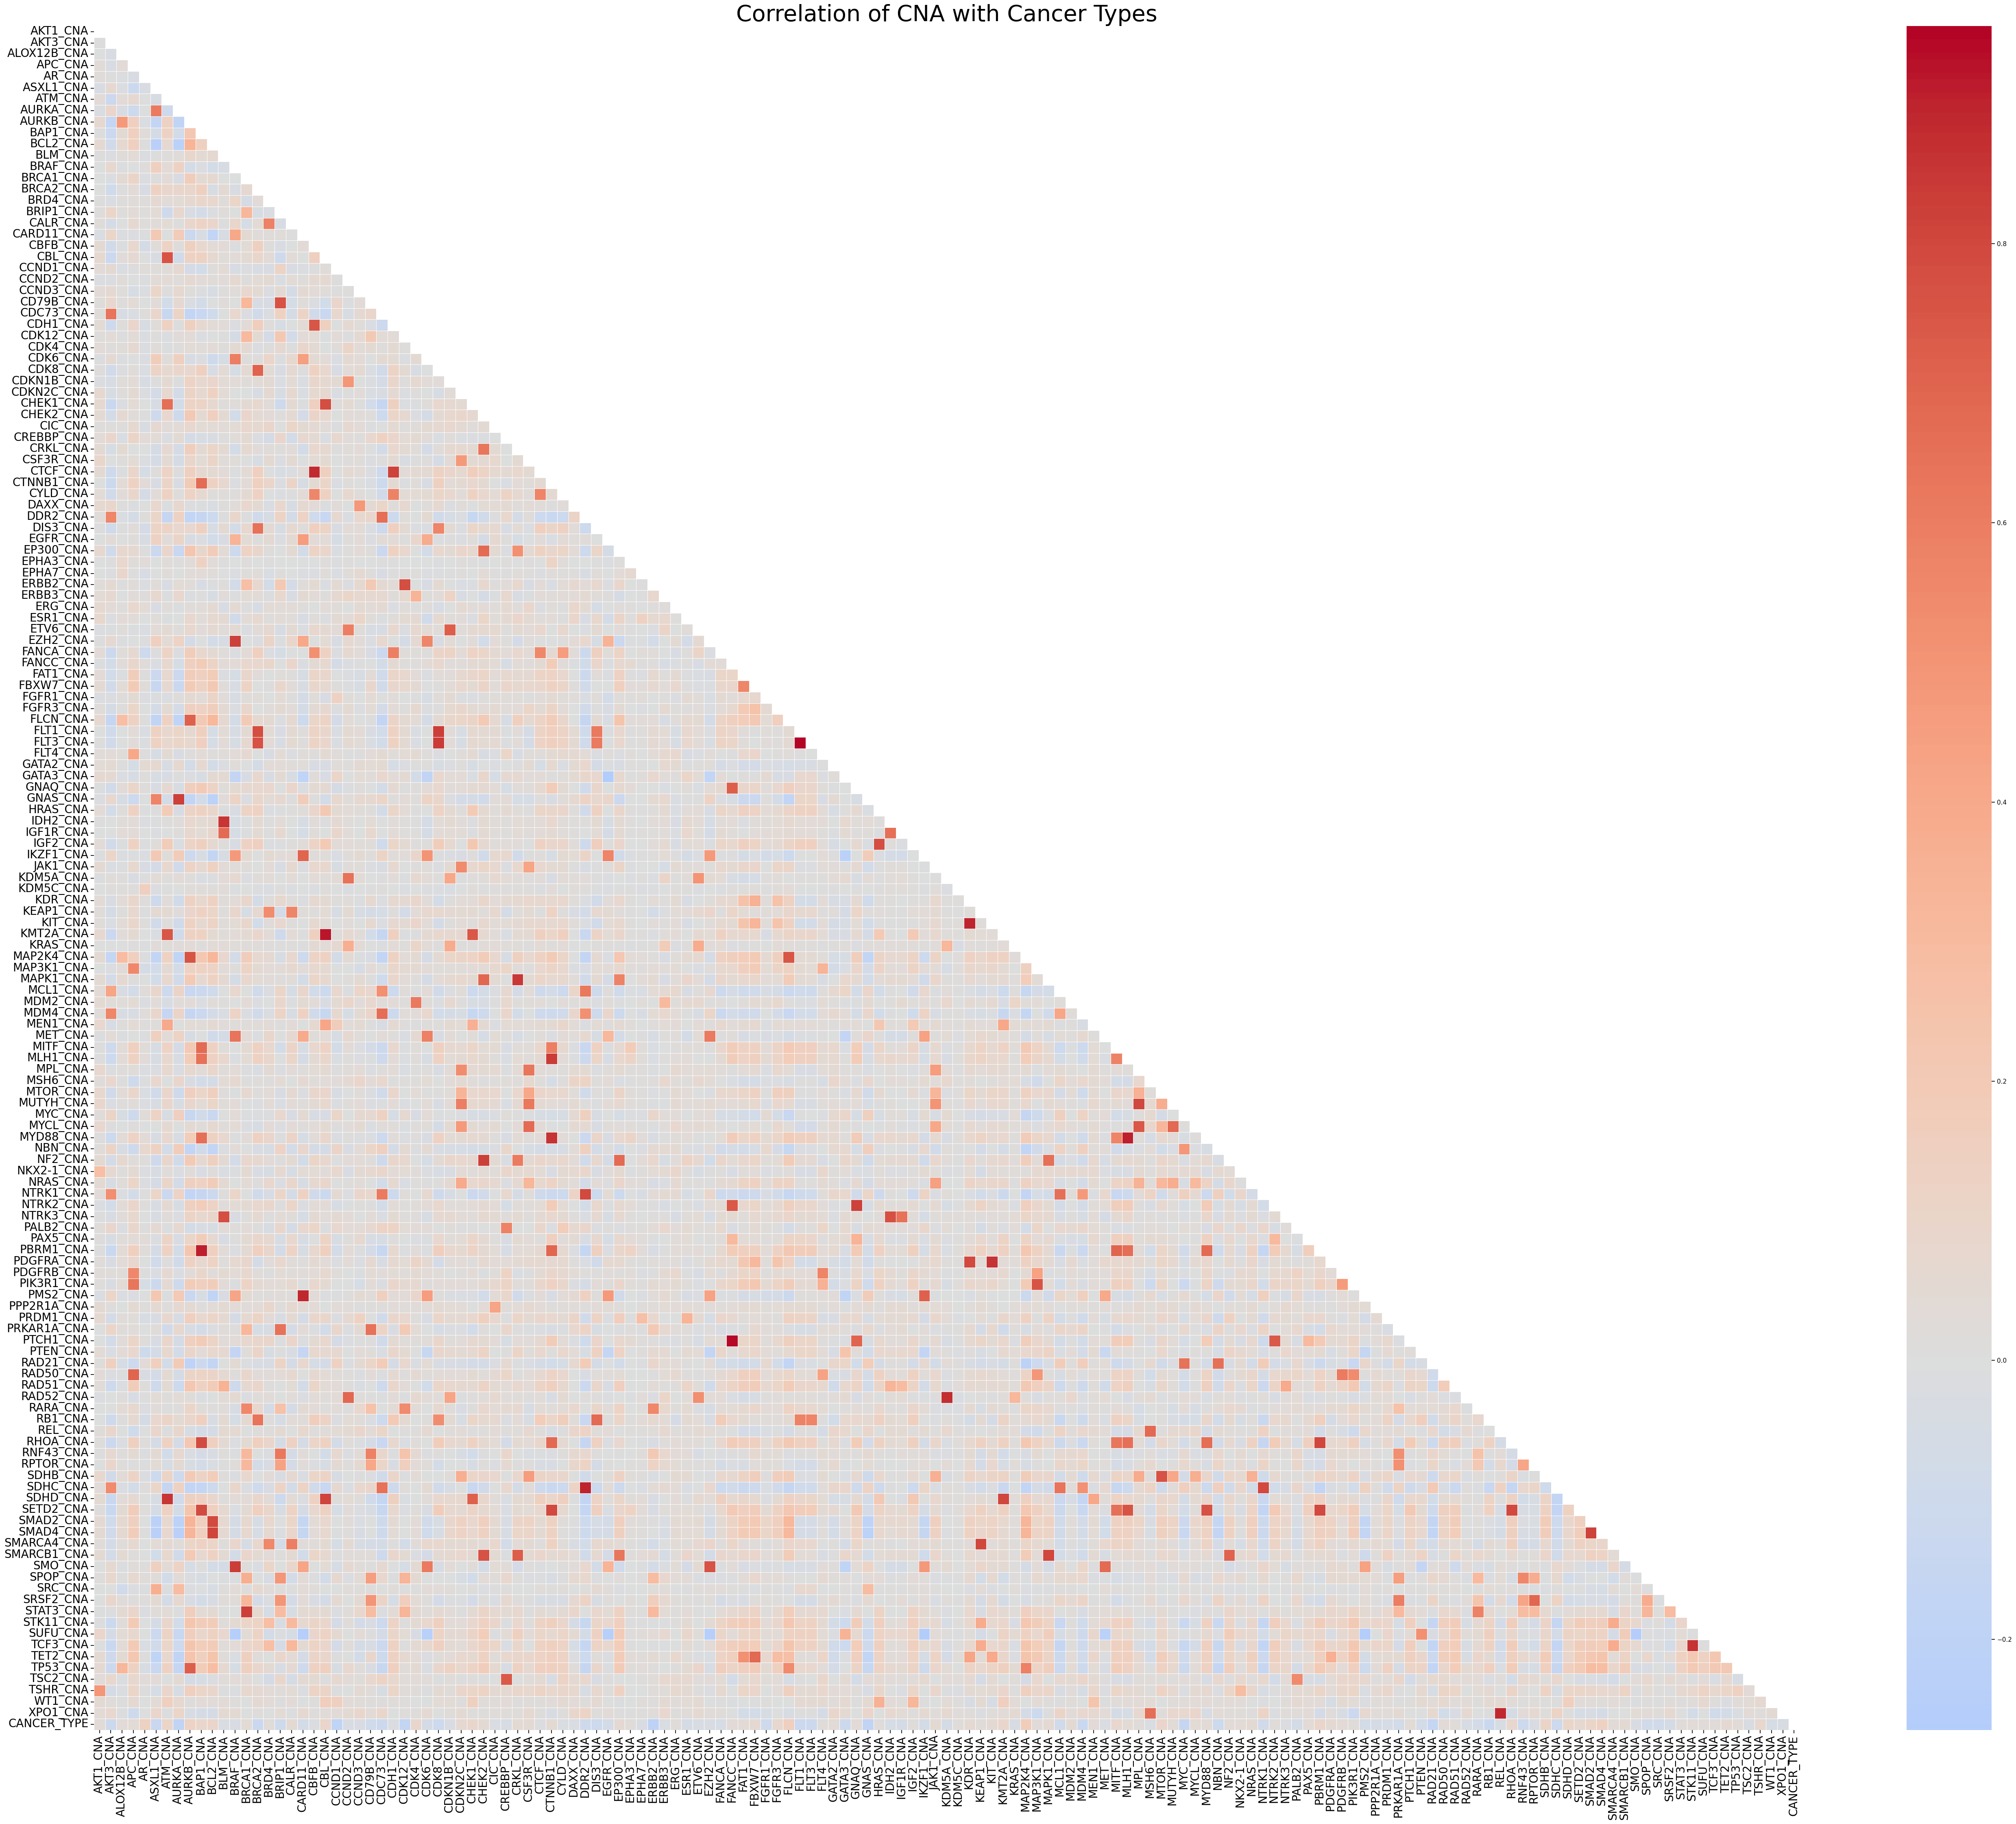

In [151]:
def get_corr_heatmap(df,image_path,feature,fig_size,f_size):
    mask = np.triu(np.ones_like(df, dtype=bool))
    plt.figure(figsize=(fig_size[0],fig_size[1]))
    sns.set_context("notebook")
    sns.heatmap(df,mask=mask ,annot=False, cmap="coolwarm", center=0, linewidths=.5)
    plt.title(f'Correlation of {feature} with Cancer Types', fontsize=f_size)
    plt.xticks(fontsize=f_size/2)
    plt.yticks(fontsize=f_size/2)
    plt.tight_layout()
    plt.savefig(image_path, dpi=300)
    plt.show()

cna_corr=df[cna_columns+['CANCER_TYPE']].corr()
get_corr_heatmap(cna_corr,"corr_matrix_cna.png",'CNA',fig_size=(55, 45),f_size=40)

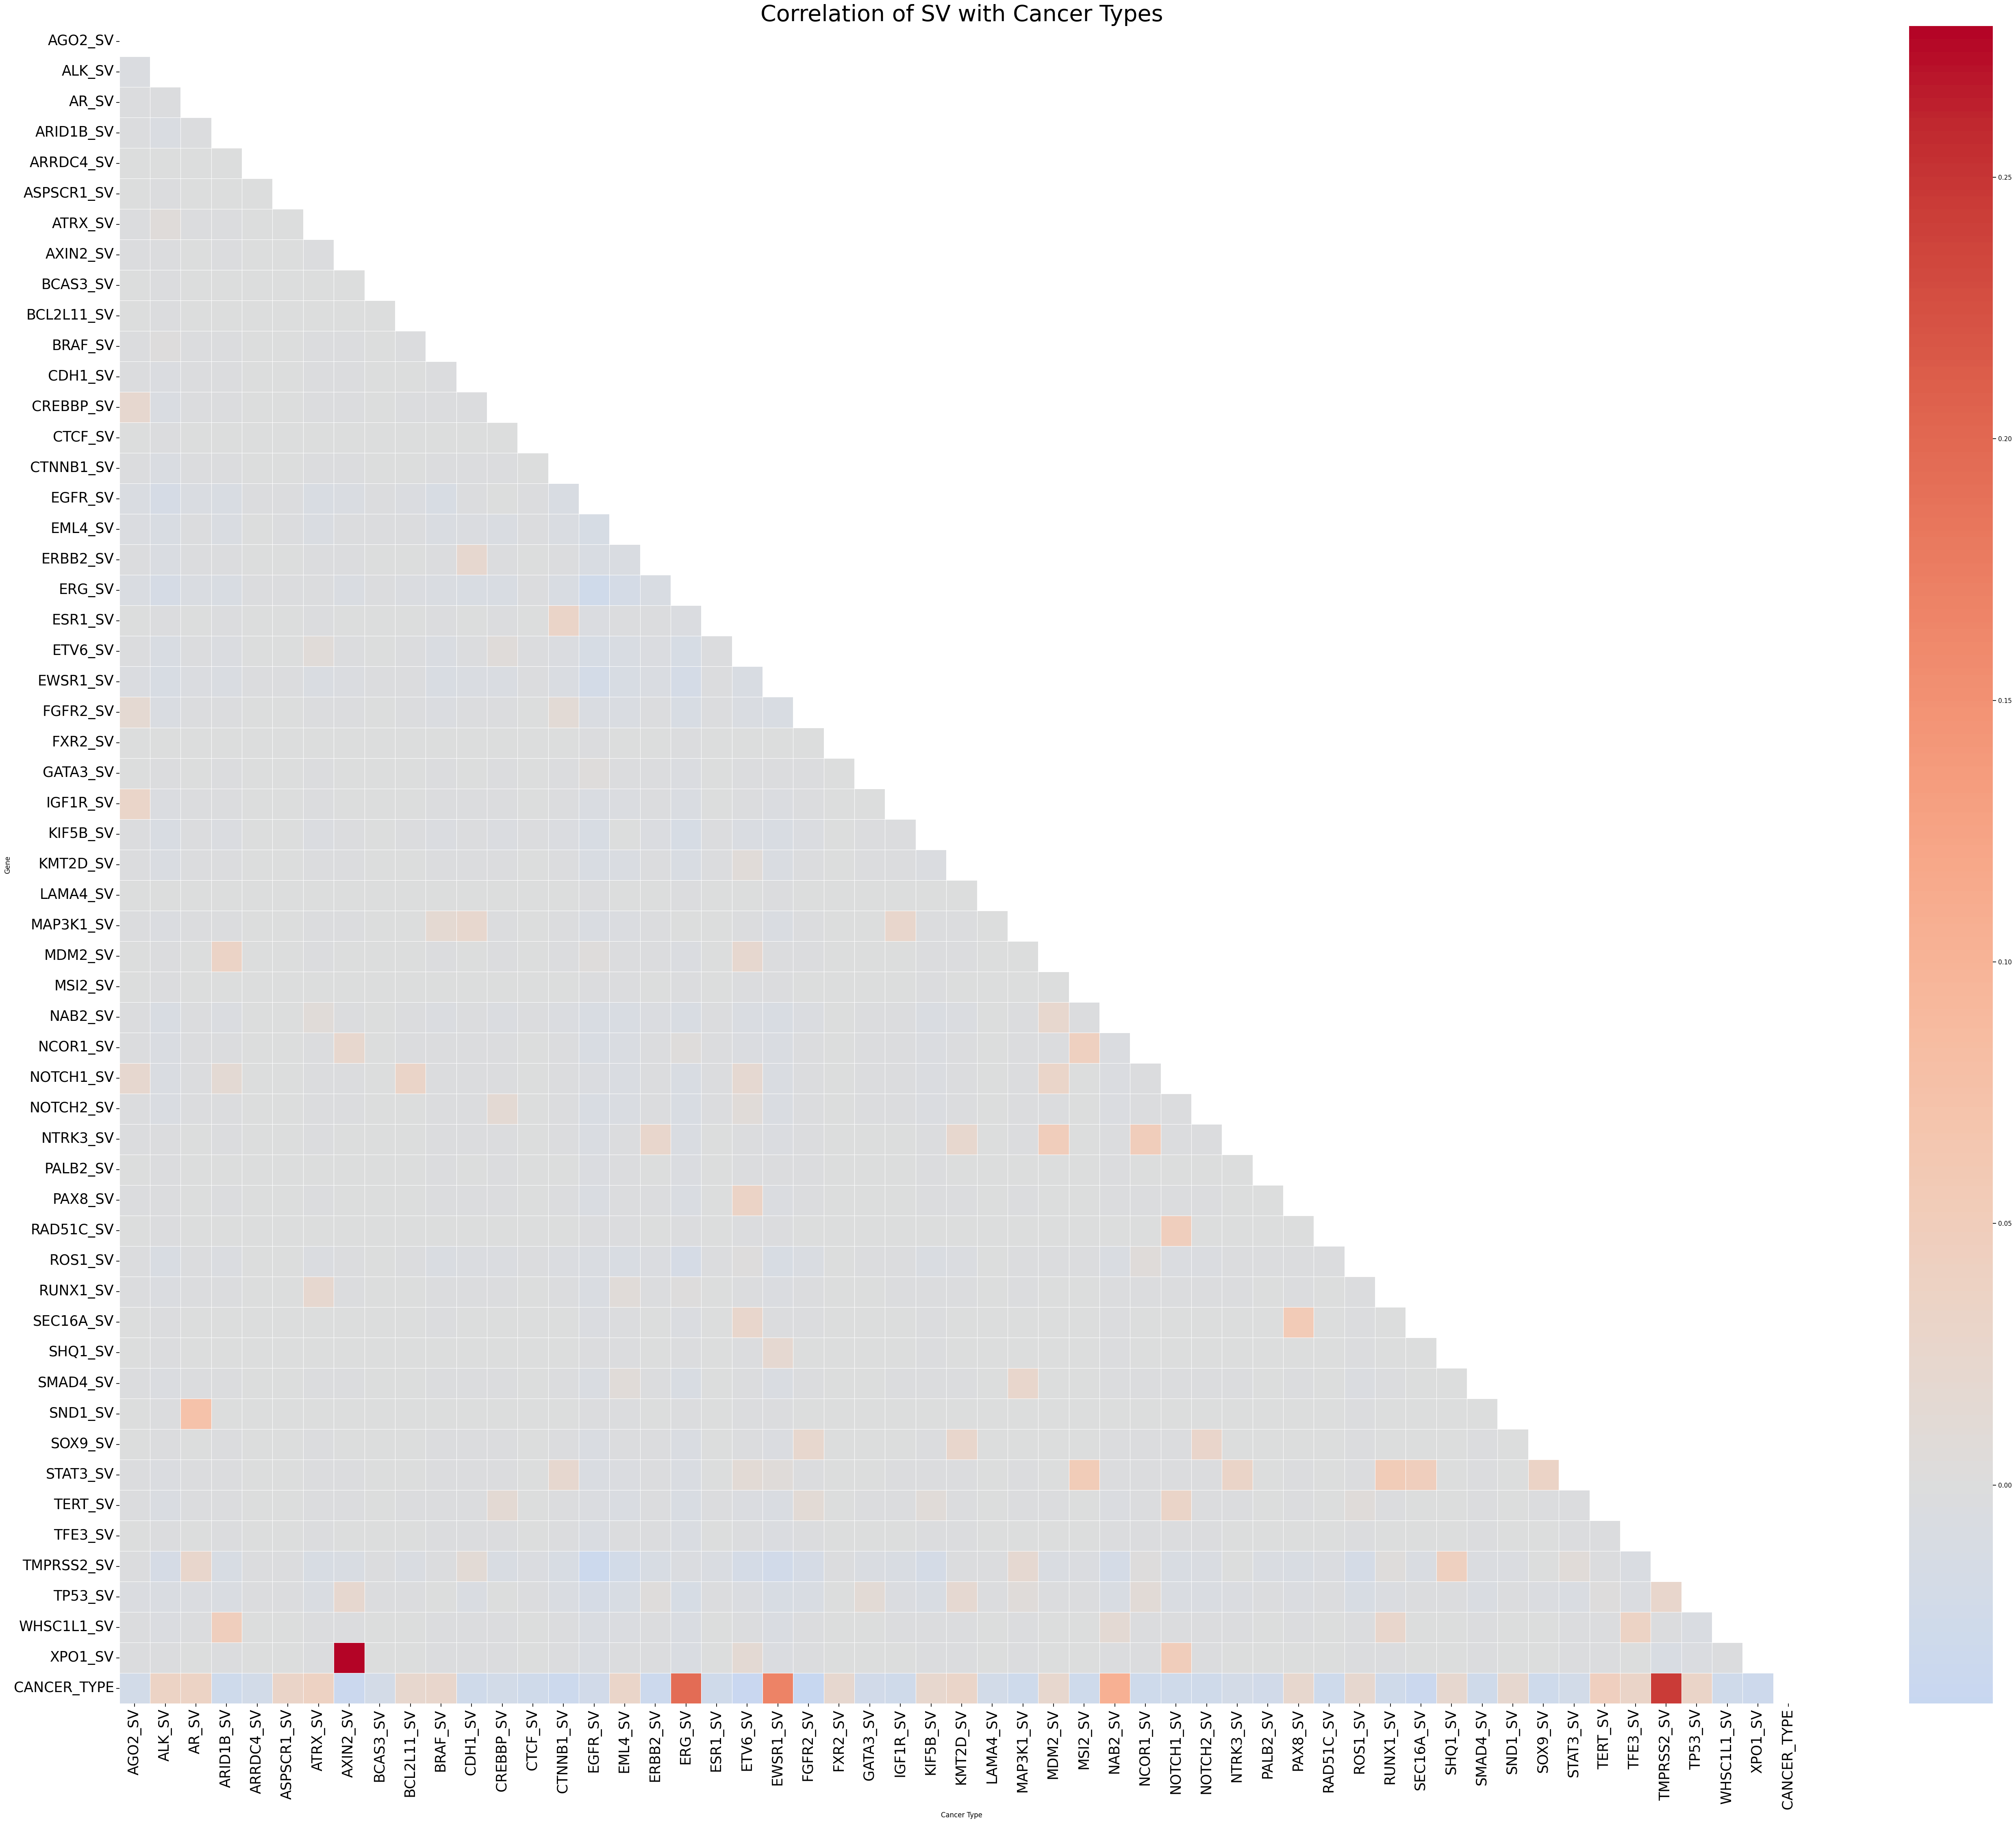

In [144]:
sv_corr=df[sv_columns+['CANCER_TYPE']].corr()
get_corr_heatmap(sv_corr,"corr_matrix_sv.png",'SV',fig_size=(55, 45),f_size=40)

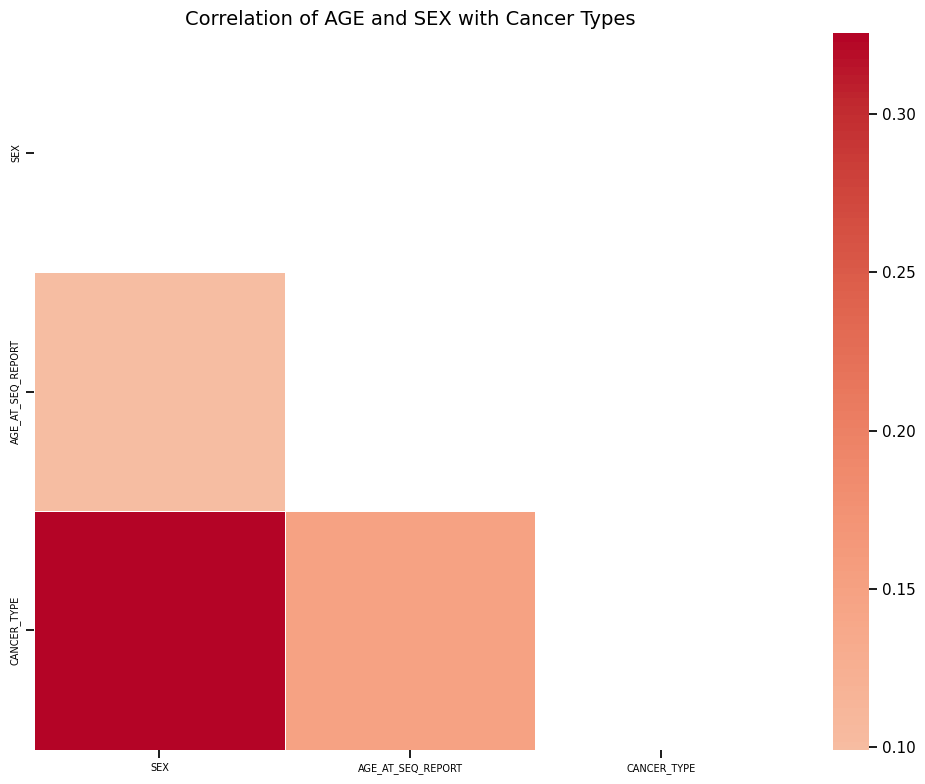

In [152]:
age_sex_corr=df[['SEX','AGE_AT_SEQ_REPORT','CANCER_TYPE']].corr()
get_corr_heatmap(age_sex_corr,"corr_matrix_age_sex.png",'AGE and SEX',fig_size=(10, 8),f_size=14)

# Feature distribution analysis

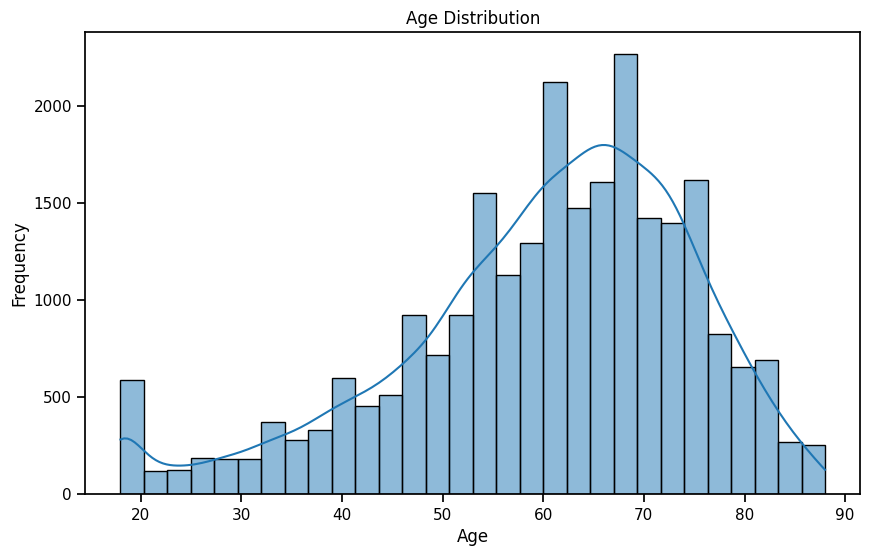

In [154]:
plt.figure(figsize=(10, 6))
sns.histplot(main_df['AGE_AT_SEQ_REPORT'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('Age_distribution.png')
plt.show()

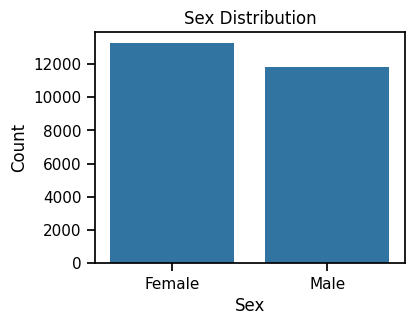

In [156]:
plt.figure(figsize=(4, 3))
sns.countplot(x='SEX', data=main_df)
plt.title('Sex Distribution')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.savefig('Sex Distribution.png',bbox_inches = 'tight')
plt.show()

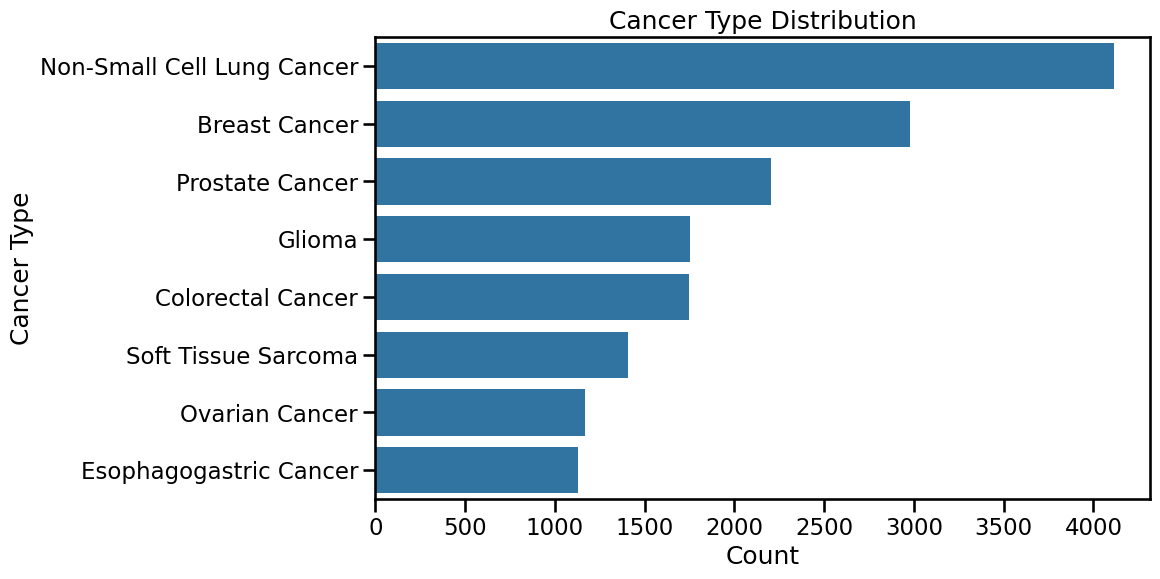

In [67]:
plt.figure(figsize=(10, 6))
sns.set_context("talk")
sns.countplot(y='CANCER_TYPE', data=df, order=df['CANCER_TYPE'].value_counts().index)
plt.title('Cancer Type Distribution')
plt.xlabel('Count')
plt.ylabel('Cancer Type')
plt.show()

# Is there any pattern in the data?

Variance explained by the first two principal components: 0.16, 0.11


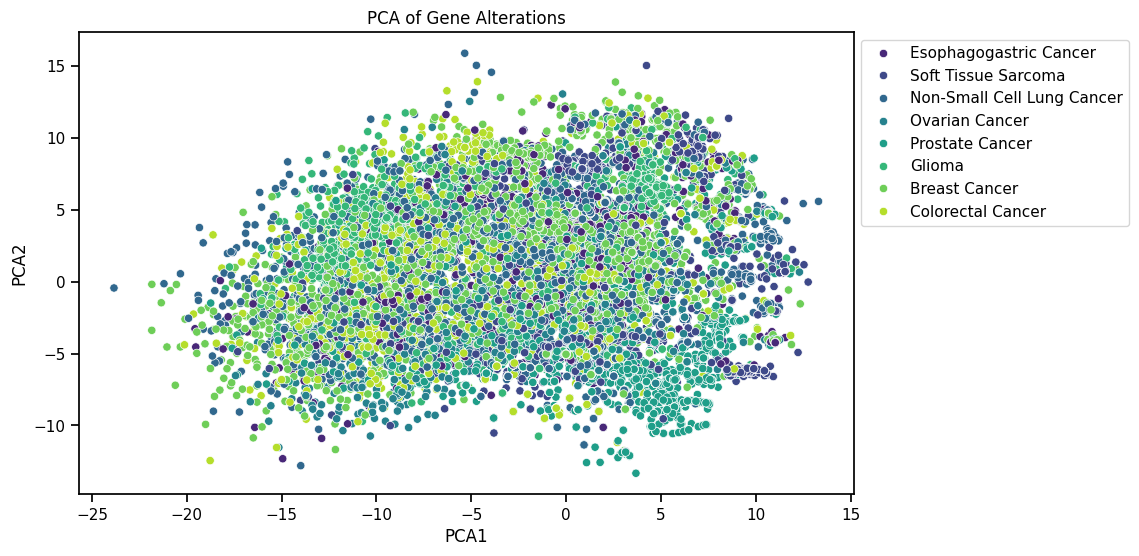

/home/afiai97/.local/lib/python3.11/site-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


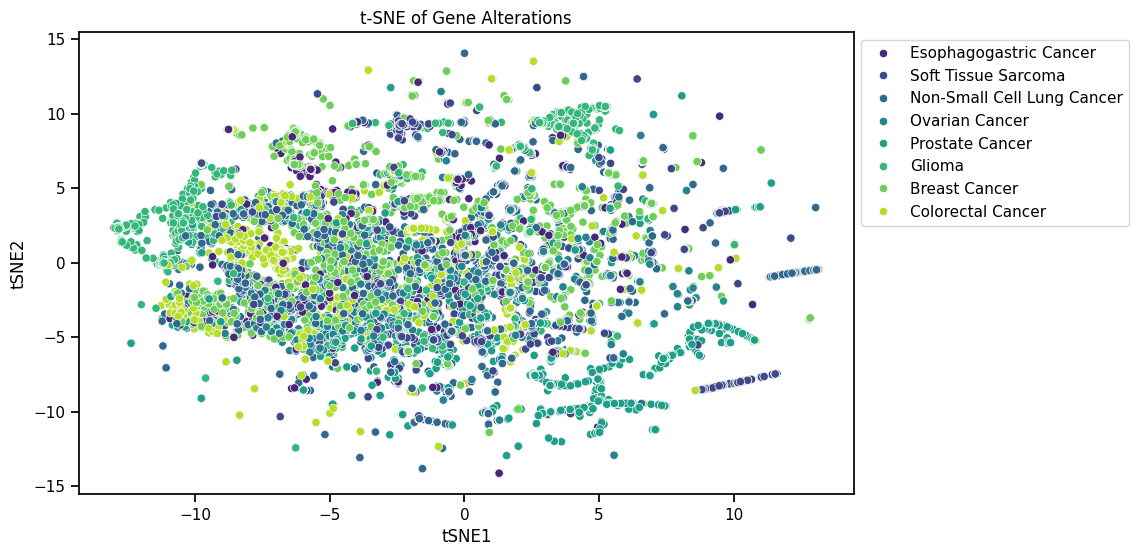

In [161]:
df_scaled = df.drop(columns=['CANCER_TYPE'])

hue_mapping=df['CANCER_TYPE'].apply(lambda x: label_encoder_cancer.inverse_transform([x])[0])
pca_full = PCA(n_components=10) 
pca_full_result = pca_full.fit_transform(df_scaled)
explained_variance_full = pca_full.explained_variance_ratio_
# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(df_scaled)
df['PCA1'] = pca_full_result[:, 0]
df['PCA2'] = pca_full_result[:, 1]

# Variance explained by PCA
explained_variance = pca_full.explained_variance_ratio_
print(f'Variance explained by the first two principal components: {explained_variance[0]:.2f}, {explained_variance[1]:.2f}')

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue=hue_mapping, data=df, palette='viridis')
plt.title('PCA of Gene Alterations')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('pca.png',bbox_inches = 'tight')
plt.show()

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=0)
tsne_result = tsne.fit_transform(df_scaled)
df['tSNE1'] = tsne_result[:, 0]
df['tSNE2'] = tsne_result[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(x='tSNE1', y='tSNE2', hue=hue_mapping, data=df, palette='viridis')
plt.title('t-SNE of Gene Alterations')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('tsne.png',bbox_inches = 'tight')
plt.show()


/home/afiai97/.local/lib/python3.11/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/afiai97/.local/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


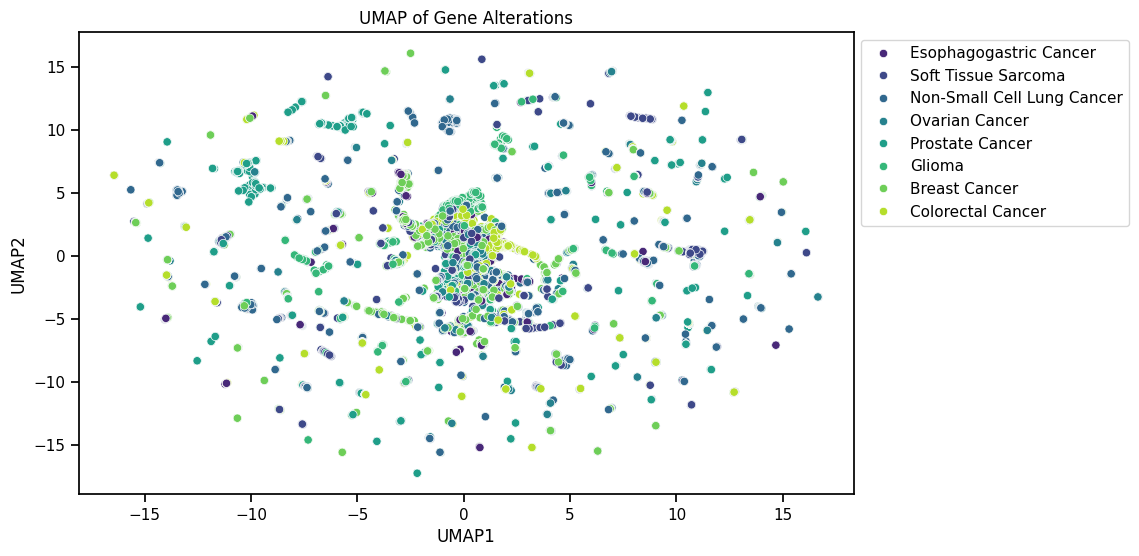

In [164]:
# UMAP
import umap.umap_ as umap
umap_reducer = umap.UMAP(n_components=2, random_state=0)
umap_result = umap_reducer.fit_transform(df_scaled)
df['UMAP1'] = umap_result[:, 0]
df['UMAP2'] = umap_result[:, 1]

# UMAP Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='UMAP1', y='UMAP2', hue=hue_mapping, data=df, palette='viridis')
plt.title('UMAP of Gene Alterations')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.savefig('umap.png',bbox_inches = 'tight')
plt.show()

### No obvious pattern. Neural Network or Decision tree based model's might be a good classifier for this problem.